# EDA & Model Attention

Explores the dataset and visualizes **where the model looks** when it reads a clock,
using Grad-CAM on the default checkpoint (`models/clock_model_unfrozen_aug_80ep.keras`).

Sections:
1. Setup
2. Dataset EDA (class balance, sample images)
3. Recap: current test-set accuracy
4. Grad-CAM: how it works here
5. Attention on correctly-classified images
6. Attention on the model's actual misreads
7. Attention on known dataset defects (blank render, mislabeled image) — do these
   visually explain the errors documented in `CHANGELOG.md`?
8. Aggregate attention across many images

Run this from anywhere in the repo; it locates `src/` relative to the repo root
regardless of the notebook's working directory.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

# Locate the repo root (this notebook lives in notebooks/, but may be launched
# from either the repo root or notebooks/ itself).
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "src").exists(), f"couldn't find src/ from {Path.cwd()}"
sys.path.insert(0, str(REPO_ROOT / "src"))

import clockmodel as cm

plt.rcParams["figure.facecolor"] = "white"
print("repo root:", REPO_ROOT)
print("default model:", cm.DEFAULT_MODEL)

I0000 00:00:1787519237.444483 1845945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787519240.439737 1845945 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


repo root: /home/kargin/Projects/personal/analog_clock_prediction
default model: /home/kargin/Projects/personal/analog_clock_prediction/models/clock_model_unfrozen_aug_80ep.keras


In [2]:
model = cm.load_model()
names = cm.class_names()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 150, 150,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 150, 150,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 150, 150,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 151, 151,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 75, 75,    │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 75, 75,    │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 75, 75,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 75, 75,    │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 75, 75,    │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 75, 75,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 75, 75,    │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 75, 75,    │        960 │ block1a_se_excit

 Total params: 11,220,159 (42.80 MB)

 Trainable params: 11,129,784 (42.46 MB)

 Non-trainable params: 90,375 (353.03 KB)

## 1. Dataset EDA

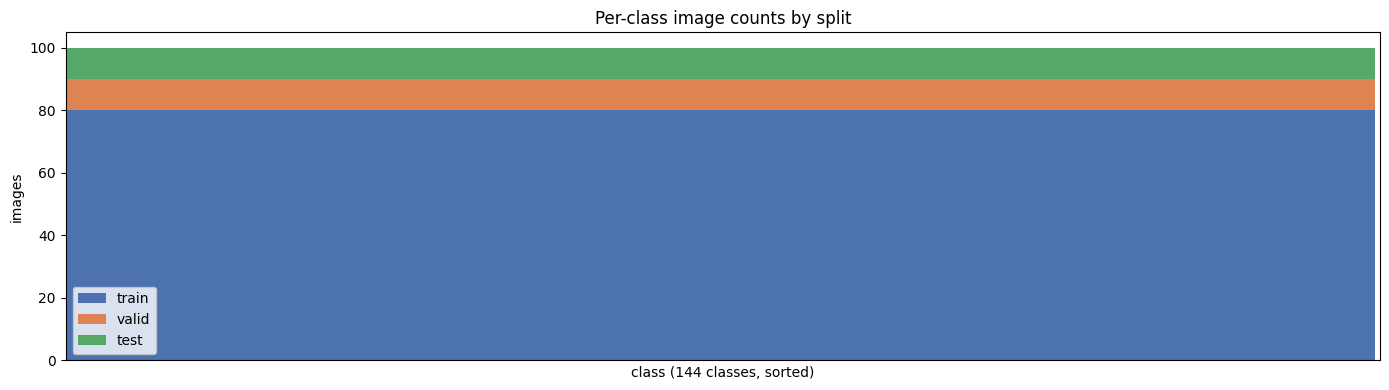

train : 11520 images, min/max per class = 80/80
valid : 1440 images, min/max per class = 10/10
test  : 1440 images, min/max per class = 10/10


In [3]:
# Class balance across splits -- should be a clean 80/10/10 per class (144 classes).
from pathlib import Path as _P

counts = {}
for split in ("train", "valid", "test"):
    per_class = [len(list((cm.DATA_DIR / split / c).glob("*.jpg"))) for c in names]
    counts[split] = per_class

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(len(names))
bottom = np.zeros(len(names))
for split, color in zip(("train", "valid", "test"), ("#4C72B0", "#DD8452", "#55A868")):
    ax.bar(x, counts[split], bottom=bottom, label=split, color=color, width=1.0)
    bottom += np.array(counts[split])
ax.set_xlim(0, len(names))
ax.set_xticks([])
ax.set_xlabel("class (144 classes, sorted)")
ax.set_ylabel("images")
ax.set_title("Per-class image counts by split")
ax.legend()
plt.tight_layout()
plt.show()

for split in ("train", "valid", "test"):
    c = counts[split]
    print(f"{split:6s}: {sum(c)} images, min/max per class = {min(c)}/{max(c)}")

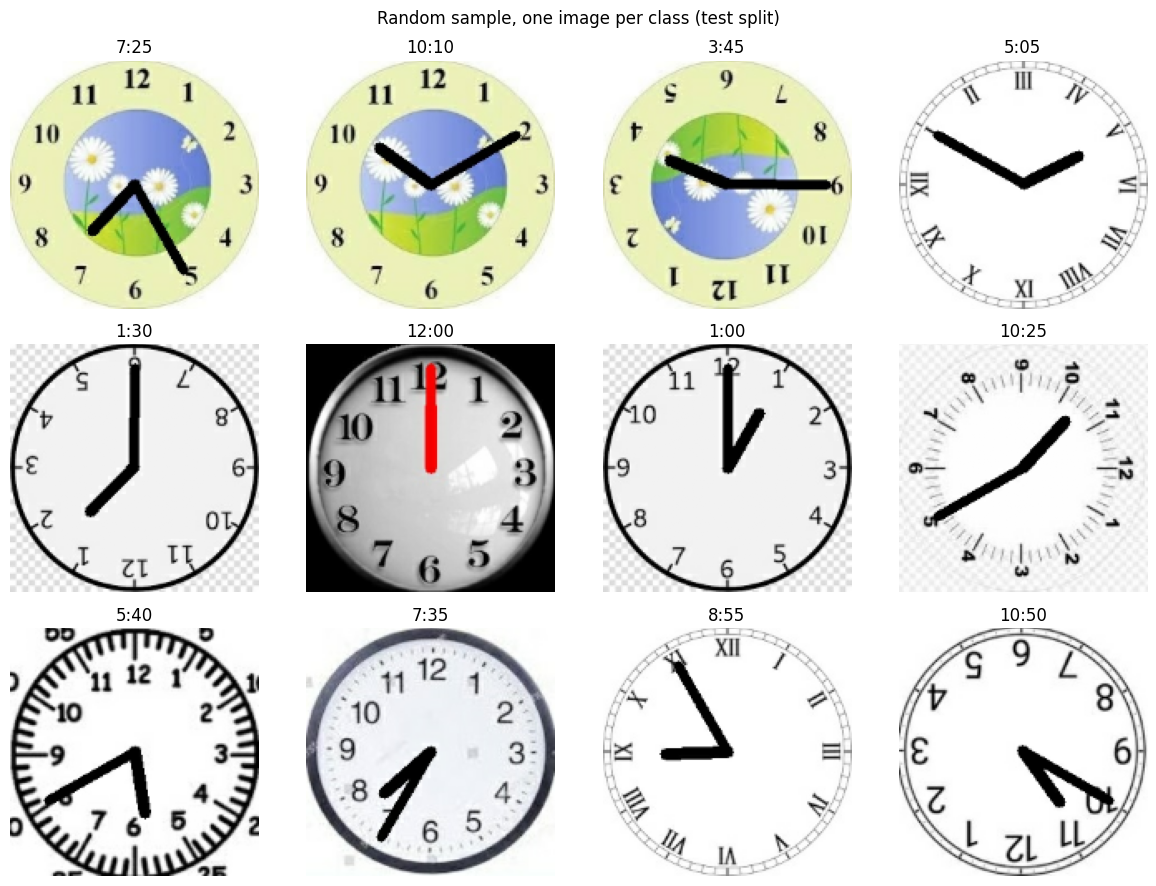

In [4]:
# A grid of raw samples across random classes, so we know what we're looking at.
rng = np.random.default_rng(0)
sample_classes = rng.choice(names, size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, cls in zip(axes.flat, sample_classes):
    imgs = sorted((cm.DATA_DIR / "test" / cls).glob("*.jpg"))
    img = cm.load_image(imgs[0]) / 255.0
    ax.imshow(img)
    ax.set_title(cm.label_to_time(cls))
    ax.axis("off")
plt.suptitle("Random sample, one image per class (test split)")
plt.tight_layout()
plt.show()

## 2. Recap: current test-set accuracy

Quick sanity check before the attention analysis -- reproduces the number in `AGENTS.md`.

In [5]:
ds = cm.make_dataset("test", batch_size=64)
probs = model.predict(ds, verbose=0)
y_true = np.concatenate([y.numpy().argmax(1) for _, y in ds])
y_pred = probs.argmax(1)
acc = (y_pred == y_true).mean()
print(f"test top-1 accuracy: {acc:.4f}  ({(y_pred != y_true).sum()} misreads / {len(y_true)} images)")

test_paths = cm.make_dataset("test", batch_size=64)
file_paths = keras.utils.image_dataset_from_directory(
    cm.DATA_DIR / "test", labels="inferred", label_mode="categorical",
    class_names=names, image_size=cm.IMG_SIZE, batch_size=64, shuffle=False,
).file_paths

Found 1440 files belonging to 144 classes.


test top-1 accuracy: 0.9958  (6 misreads / 1440 images)
Found 1440 files belonging to 144 classes.


Found 1440 files belonging to 144 classes.


## 3. Grad-CAM: how it works here

The model is EfficientNetB3 → `top_activation` (last conv feature map, 5x5x1536 at
150x150 input) → GlobalMaxPool → BatchNorm → Dense(256) → Dropout → Dense(144, softmax).

Grad-CAM takes the gradient of the predicted class's score with respect to
`top_activation`'s feature maps, global-average-pools those gradients into one
importance weight per channel, and uses them to weight-sum the feature maps into a
single 5x5 heatmap -- upsampled here to 150x150 and overlaid on the input image.
Brighter = more influence on the model's prediction for that class.

In [6]:
GRADCAM_LAYER = "top_activation"

def make_gradcam(img_float, model, pred_index=None, layer_name=GRADCAM_LAYER):
    """img_float: HxWx3 raw [0,255] float array (clockmodel.load_image output)."""
    grad_model = keras.Model(model.inputs, [model.get_layer(layer_name).output, model.output])
    img_batch = tf.convert_to_tensor(img_float[None, ...])

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_batch)
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_score = preds[:, pred_index]

    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index, preds[0].numpy()


def show_gradcam(ax, path, model, true_label=None, layer_name=GRADCAM_LAYER):
    img = cm.load_image(path)
    heatmap, pred_idx, probs = make_gradcam(img, model, layer_name=layer_name)
    heatmap_big = tf.image.resize(heatmap[..., None], cm.IMG_SIZE).numpy().squeeze()

    ax.imshow(img / 255.0)
    ax.imshow(heatmap_big, cmap="jet", alpha=0.45)
    ax.axis("off")

    pred_label = names[pred_idx]
    title = f"pred {cm.label_to_time(pred_label)} ({probs[pred_idx]:.2f})"
    if true_label is not None:
        true_time = cm.label_to_time(true_label)
        ok = pred_label == true_label
        title = f"true {true_time} -> {title}"
        ax.set_title(title, color="black" if ok else "crimson", fontsize=9)
    else:
        ax.set_title(title, fontsize=9)
    return pred_idx, probs

## 4. Attention on correctly-classified images

Random sample of correct test predictions. If the model is reading hand *position*
(as the rotation-invariance finding in `AGENTS.md` implies -- predictions are exactly
invariant to 90/180/270 degree rotation), the hot region should track the hands, not a
fixed part of the frame.

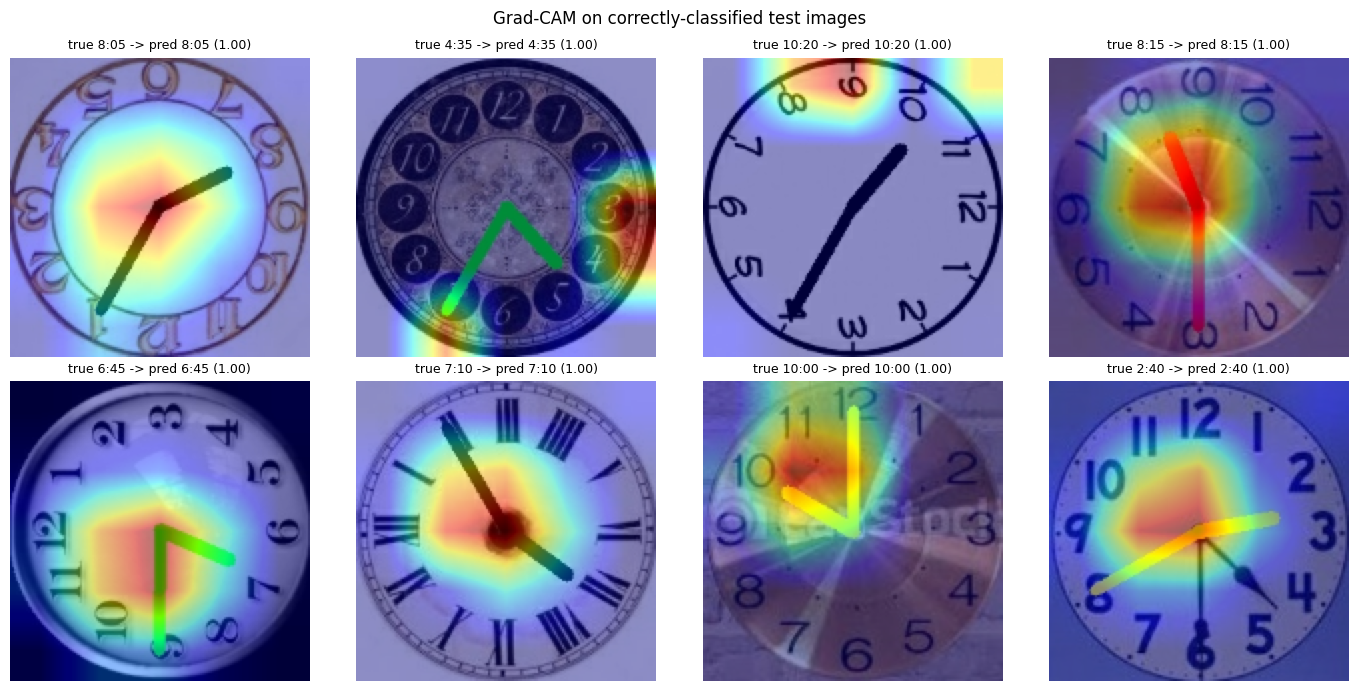

In [7]:
correct_idx = np.flatnonzero(y_pred == y_true)
sample_idx = rng.choice(correct_idx, size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.flat, sample_idx):
    show_gradcam(ax, file_paths[i], model, true_label=names[y_true[i]])
plt.suptitle("Grad-CAM on correctly-classified test images")
plt.tight_layout()
plt.show()

## 5. Attention on the model's actual misreads

The current default checkpoint's test-split misreads (see `AGENTS.md` / `CHANGELOG.md`
for the full-dataset version of this diagnosis).

6 misread(s) in the test split


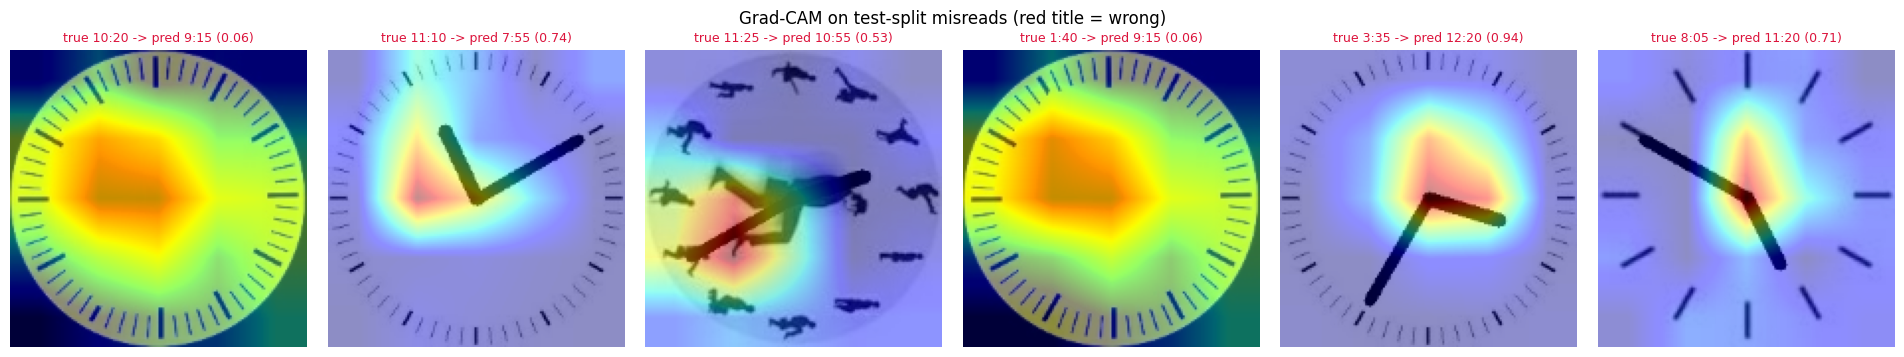

In [8]:
misread_idx = np.flatnonzero(y_pred != y_true)
print(f"{len(misread_idx)} misread(s) in the test split")

n = len(misread_idx)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.6))
if n == 1:
    axes = [axes]
for ax, i in zip(axes, misread_idx):
    show_gradcam(ax, file_paths[i], model, true_label=names[y_true[i]])
plt.suptitle("Grad-CAM on test-split misreads (red title = wrong)")
plt.tight_layout()
plt.show()

## 6. Attention on known dataset defects

`CHANGELOG.md` (2026-08-23, "33-error diagnosis") found that most of the full-dataset
errors are dataset defects, not model errors: 19 classes have a **blank dial render**
(no hands drawn) at file index `36`, and one further image
(`valid/8-50/36.jpg`) is **mislabeled/mis-rendered** -- hands drawn near 12:05,
not 8:50. Grad-CAM should make both visually obvious: nothing coherent to attend to
for the blank one, and attention on the *drawn* hands (near 12) for the mislabeled one,
regardless of what the folder name claims.

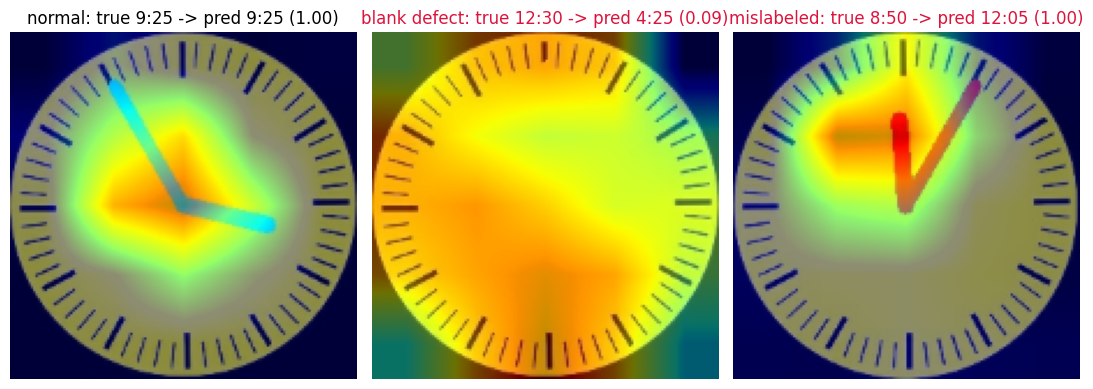

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))

# A normal image for contrast.
show_gradcam(axes[0], cm.DATA_DIR / "train" / "9-25" / "36.jpg", model, true_label="9-25")
axes[0].set_ylabel("normal (has hands)")

# The blank-dial defect.
show_gradcam(axes[1], cm.DATA_DIR / "train" / "12-30" / "36.jpg", model, true_label="12-30")

# The mislabeled/mis-rendered image.
show_gradcam(axes[2], cm.DATA_DIR / "valid" / "8-50" / "36.jpg", model, true_label="8-50")

axes[0].set_title("normal: " + axes[0].get_title())
axes[1].set_title("blank defect: " + axes[1].get_title())
axes[2].set_title("mislabeled: " + axes[2].get_title())
plt.tight_layout()
plt.show()

## 7. Aggregate attention across many images

Average Grad-CAM heatmap over a larger random sample of correct test predictions,
in a shared frame (heatmaps aren't re-centered on the hands -- this shows *where in
the image* the model tends to look on average, not the hand-tracking behavior from
section 4).

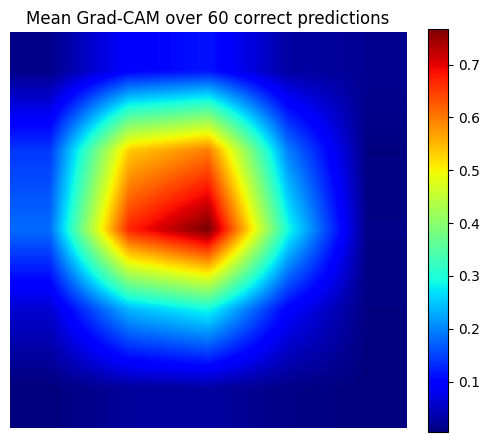

In [10]:
sample_idx = rng.choice(correct_idx, size=60, replace=False)
acc_heatmap = np.zeros(cm.IMG_SIZE, dtype=np.float32)

for i in sample_idx:
    img = cm.load_image(file_paths[i])
    heatmap, _, _ = make_gradcam(img, model, pred_index=int(y_true[i]))
    heatmap_big = tf.image.resize(heatmap[..., None], cm.IMG_SIZE).numpy().squeeze()
    acc_heatmap += heatmap_big

acc_heatmap /= len(sample_idx)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(acc_heatmap, cmap="jet")
ax.set_title(f"Mean Grad-CAM over {len(sample_idx)} correct predictions")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Notes

- This notebook reads the checkpoint at `models/clock_model_unfrozen_aug_80ep.keras`
  (the repo default per `src/clockmodel.py`); rerun after retraining to see how
  attention shifts.
- Findings from running this are worth folding back into `AGENTS.md` /
  `CHANGELOG.md` if they change or confirm the existing "reads dial numerals, not
  hand angles" claim -- this notebook is the first time that's been checked
  visually rather than only via the rotation-invariance test.